In [2]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt
import h5py
import numpy as np
import random
import bacco

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import emcee
import corner

In [4]:
import os
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

In [5]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

### Get Parameters

In [6]:
name_list = ['LH_{:d}'.format(i) for i in range(30)] + ['fiducial']

In [18]:
def pars(i, mstar):

    arr = np.vstack( ( mstar, np.ones(len(mstar)) * wind_en[i],\
                        np.ones(len(mstar)) * wind_vel[i],\
                        np.ones(len(mstar)) * rho_rec[i],\
                        np.ones(len(mstar)) * sf_ts[i],\
                        np.ones(len(mstar)) * ef_kin[i],\
                        np.ones(len(mstar)) * ef_high[i],\
                        np.ones(len(mstar)) * f_re[i])).T

    return arr

In [27]:
wind_en, wind_vel, rho_rec, sf_ts, ef_kin, ef_high, f_re = utils.get_parameters()
theta_fid = torch.asarray([wind_en[-1], wind_vel[-1], rho_rec[-1], sf_ts[-1], ef_kin[-1], ef_high[-1], f_re[-1]])

In [19]:
Nbins_smf = 10

z_choice = 0.25
zoom_smf = {}

zoom_base = "/cosmos_storage/home/fgmaion/MTNG-resims/results/smf_high_z"

for i in range(len(name_list)):
    zoom_smf[name_list[i]] = np.load("{:s}/smf_{:s}_Nbins10_z{:.2f}.npy".format(zoom_base, name_list[i], z_choice), allow_pickle=True)[0]

In [20]:
# Filter NaNs
for i in range(len(name_list)):
    mask = ~np.isnan(zoom_smf[name_list[i]]['smf'][0]) & ~np.isnan(zoom_smf[name_list[i]]['mstar'][0])
    
    zoom_smf[name_list[i]]['smf'][0] = zoom_smf[name_list[i]]['smf'][0][mask]
    zoom_smf[name_list[i]]['mstar'][0] = zoom_smf[name_list[i]]['mstar'][0][mask]

In [282]:
smf_draws = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/smf/smf_draws/smf_draws100_nbins10.npy", allow_pickle=True).item()

err_smf = np.std(smf_draws['ens_smf'], axis=0)
err_log_smf = torch.asarray(err_smf / np.mean(smf_draws['ens_smf'], axis=0) / np.log(10), dtype=torch.float)

### Now look at model trained with full data

In [12]:
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/scripts/train")
from GP_models import SMF_Model, fgas_Model

In [26]:
model_smf = {}
likelihood_smf = {}

z_list = [0.25, 0.3, 0.5, 0.7]

for i in range(len(z_list)):
    model_smf[i] = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_smf_z{:.2f}.pth".format(z_list[i]))
    likelihood_smf[i] = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_smf_z{:.2f}.pth".format(z_list[i]))

    model_smf[i].eval()
    likelihood_smf[i].eval()

/tmp/ipykernel_333953/1456670022.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_smf[i] = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/ful

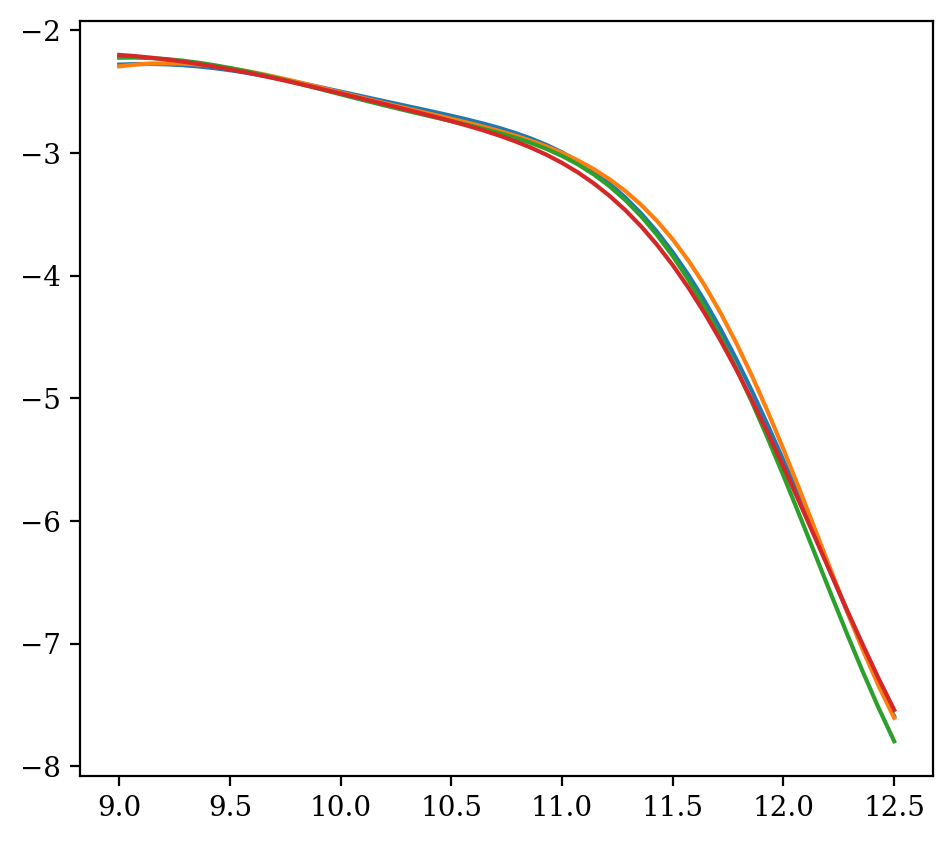

In [31]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

mstar_test = np.linspace(9,12.5,50)

for i in range(len(z_list)):
    mu_fid, var_fid = model_smf[i](torch.asarray(theta_vars[0], dtype=torch.float)).mean.detach().numpy(), model_smf[i](torch.asarray(theta_vars[2], dtype=torch.float)).variance.detach().numpy()

    ax.plot(mstar_test, mu_fid, label="GP prediction z={:.2f}".format(z_list[i]))

In [17]:
def get_theta_1p_vars(param_num, mstar, nvars):
    fid_theta = np.array([wind_en[30], wind_vel[30], rho_rec[30], sf_ts[30], ef_kin[30], ef_high[30], f_re[30]])

    theta_1p_vars = {}

    delta = 2 / nvars
    for i in range(nvars+1):
        par_array = np.copy(fid_theta)
        par_array[param_num] += (i - nvars//2) * delta
        theta_1p_vars[i] = np.vstack( ( mstar, np.ones(len(mstar)) * par_array[0],\
                                        np.ones(len(mstar)) * par_array[1],\
                                        np.ones(len(mstar)) * par_array[2],\
                                        np.ones(len(mstar)) * par_array[3],\
                                        np.ones(len(mstar)) * par_array[4],\
                                        np.ones(len(mstar)) * par_array[5],\
                                        np.ones(len(mstar)) * par_array[6])).T

    return theta_1p_vars

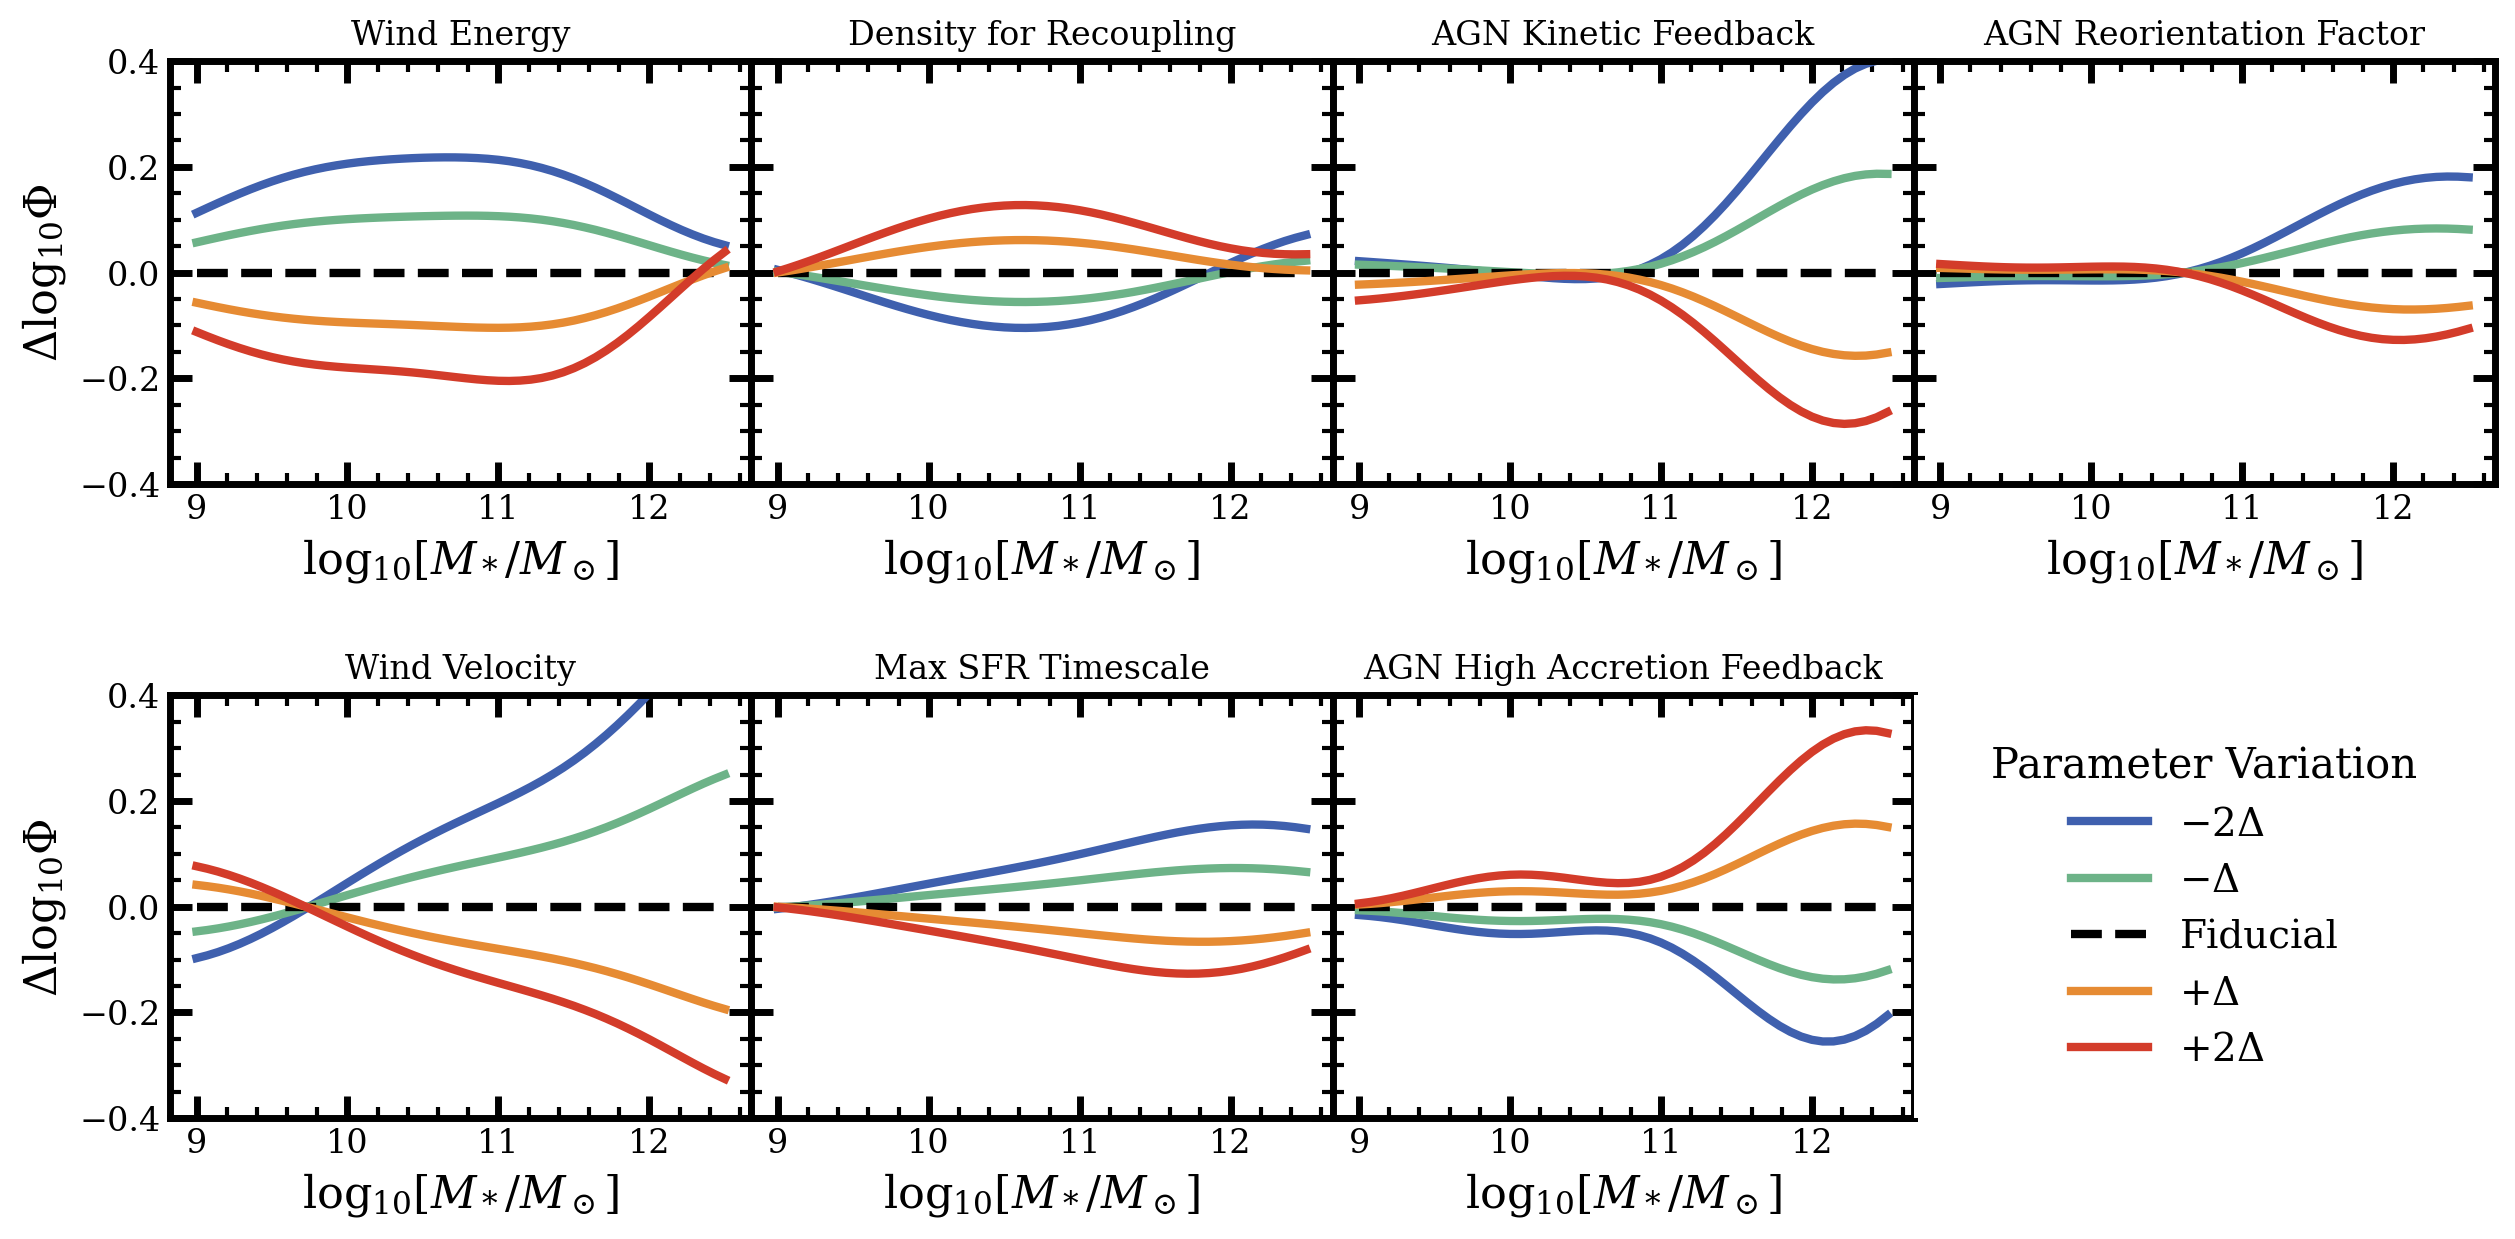

In [24]:
fig, ax = plt.subplots(2, 4, dpi=200, sharey=False, figsize=(15,7))

# Paul Tol's discrete rainbow scheme - selecting 4 well-separated colors
# for the -2Δ, -Δ, +Δ, +2Δ variations (Fiducial stays black)
tol_rainbow = ['#3F60AE', '#6DB388', '#E68B33', '#D33C2A']  # blue, green, orange, red

mstar_test = np.linspace(9,12.5,50)
names = ['Wind Energy', 'Wind Velocity', 'Density for Recoupling', 'Max SFR Timescale', 'AGN Kinetic Feedback', 'AGN High Accretion Feedback', 'AGN Reorientation Factor']

for ax_i in np.ndarray.flatten(ax):
    ax_i.set_ylim(-0.4,0.4)
    # Thicker plot edges
    for spine in ax_i.spines.values():
        spine.set_linewidth(2.5)

    # Major and minor ticks
    ax_i.tick_params(axis='both', which='major', width=2.5, length=8, labelsize=12, direction='in', right=True, top=True)
    ax_i.tick_params(axis='both', which='minor', width=1.5, length=4, direction='in', right=True, top=True)
    ax_i.minorticks_on()

labels=['$-2\Delta$', '$-\Delta$', 'Fiducial', '$+\Delta$', '$+2\Delta$']

# Map n=0,1,3,4 to tol_rainbow indices 0,1,2,3
color_map = {0: tol_rainbow[0], 1: tol_rainbow[1], 3: tol_rainbow[2], 4: tol_rainbow[3]}

for i in range(2):
    for j in range(4):
        if 2*j+i >= 7:
            ax[i,j].set_xticks([])
            ax[i,j].set_yticks([])
            for spine in ax[i,j].spines.values():
                spine.set_visible(False)
            ax[i,j].minorticks_off()
            continue

        ax[i,j].set_title(names[2*j+i])
        ax[i,j].set_xlabel(r"$\log_{10}[M_*/M_\odot]$", fontsize=16)
        theta_vars = get_theta_1p_vars(2*j+i, mstar_test, 5)

        mu_fid, var_fid = model_smf(torch.asarray(theta_vars[2], dtype=torch.float)).mean.detach().numpy(), model_smf(torch.asarray(theta_vars[2], dtype=torch.float)).variance.detach().numpy()

        for n in range(5):
            mu_pred, var = model_smf(torch.asarray(theta_vars[n], dtype=torch.float)).mean.detach().numpy(), model_smf(torch.asarray(theta_vars[n], dtype=torch.float)).variance.detach().numpy()
            if n == 2:
                ax[i,j].plot(mstar_test, mu_pred - mu_fid, label="Fiducial", ls='--', color='k', lw=3)
            else:
                ax[i,j].plot(mstar_test, mu_pred - mu_fid, color=color_map[n], label=labels[n], lw=3)

for i in range(3):
    ax[0,i+1].set_yticklabels([])
    ax[1,i+1].set_yticklabels([])

# Y-axis labels on the leftmost column
ax[0,0].set_ylabel(r"$\Delta \log_{10}\Phi$", fontsize=16)
ax[1,0].set_ylabel(r"$\Delta \log_{10}\Phi$", fontsize=16)

# Legend in the empty panel
handles, leg_labels = ax[0,0].get_legend_handles_labels()
order = [0, 1, 2, 3, 4]
handles = [handles[k] for k in order]
leg_labels = [leg_labels[k] for k in order]

ax[1,3].legend(handles, leg_labels, loc='center', fontsize=14, frameon=False, title='Parameter Variation', title_fontsize=15)

plt.subplots_adjust(wspace=0.0, hspace=0.5)

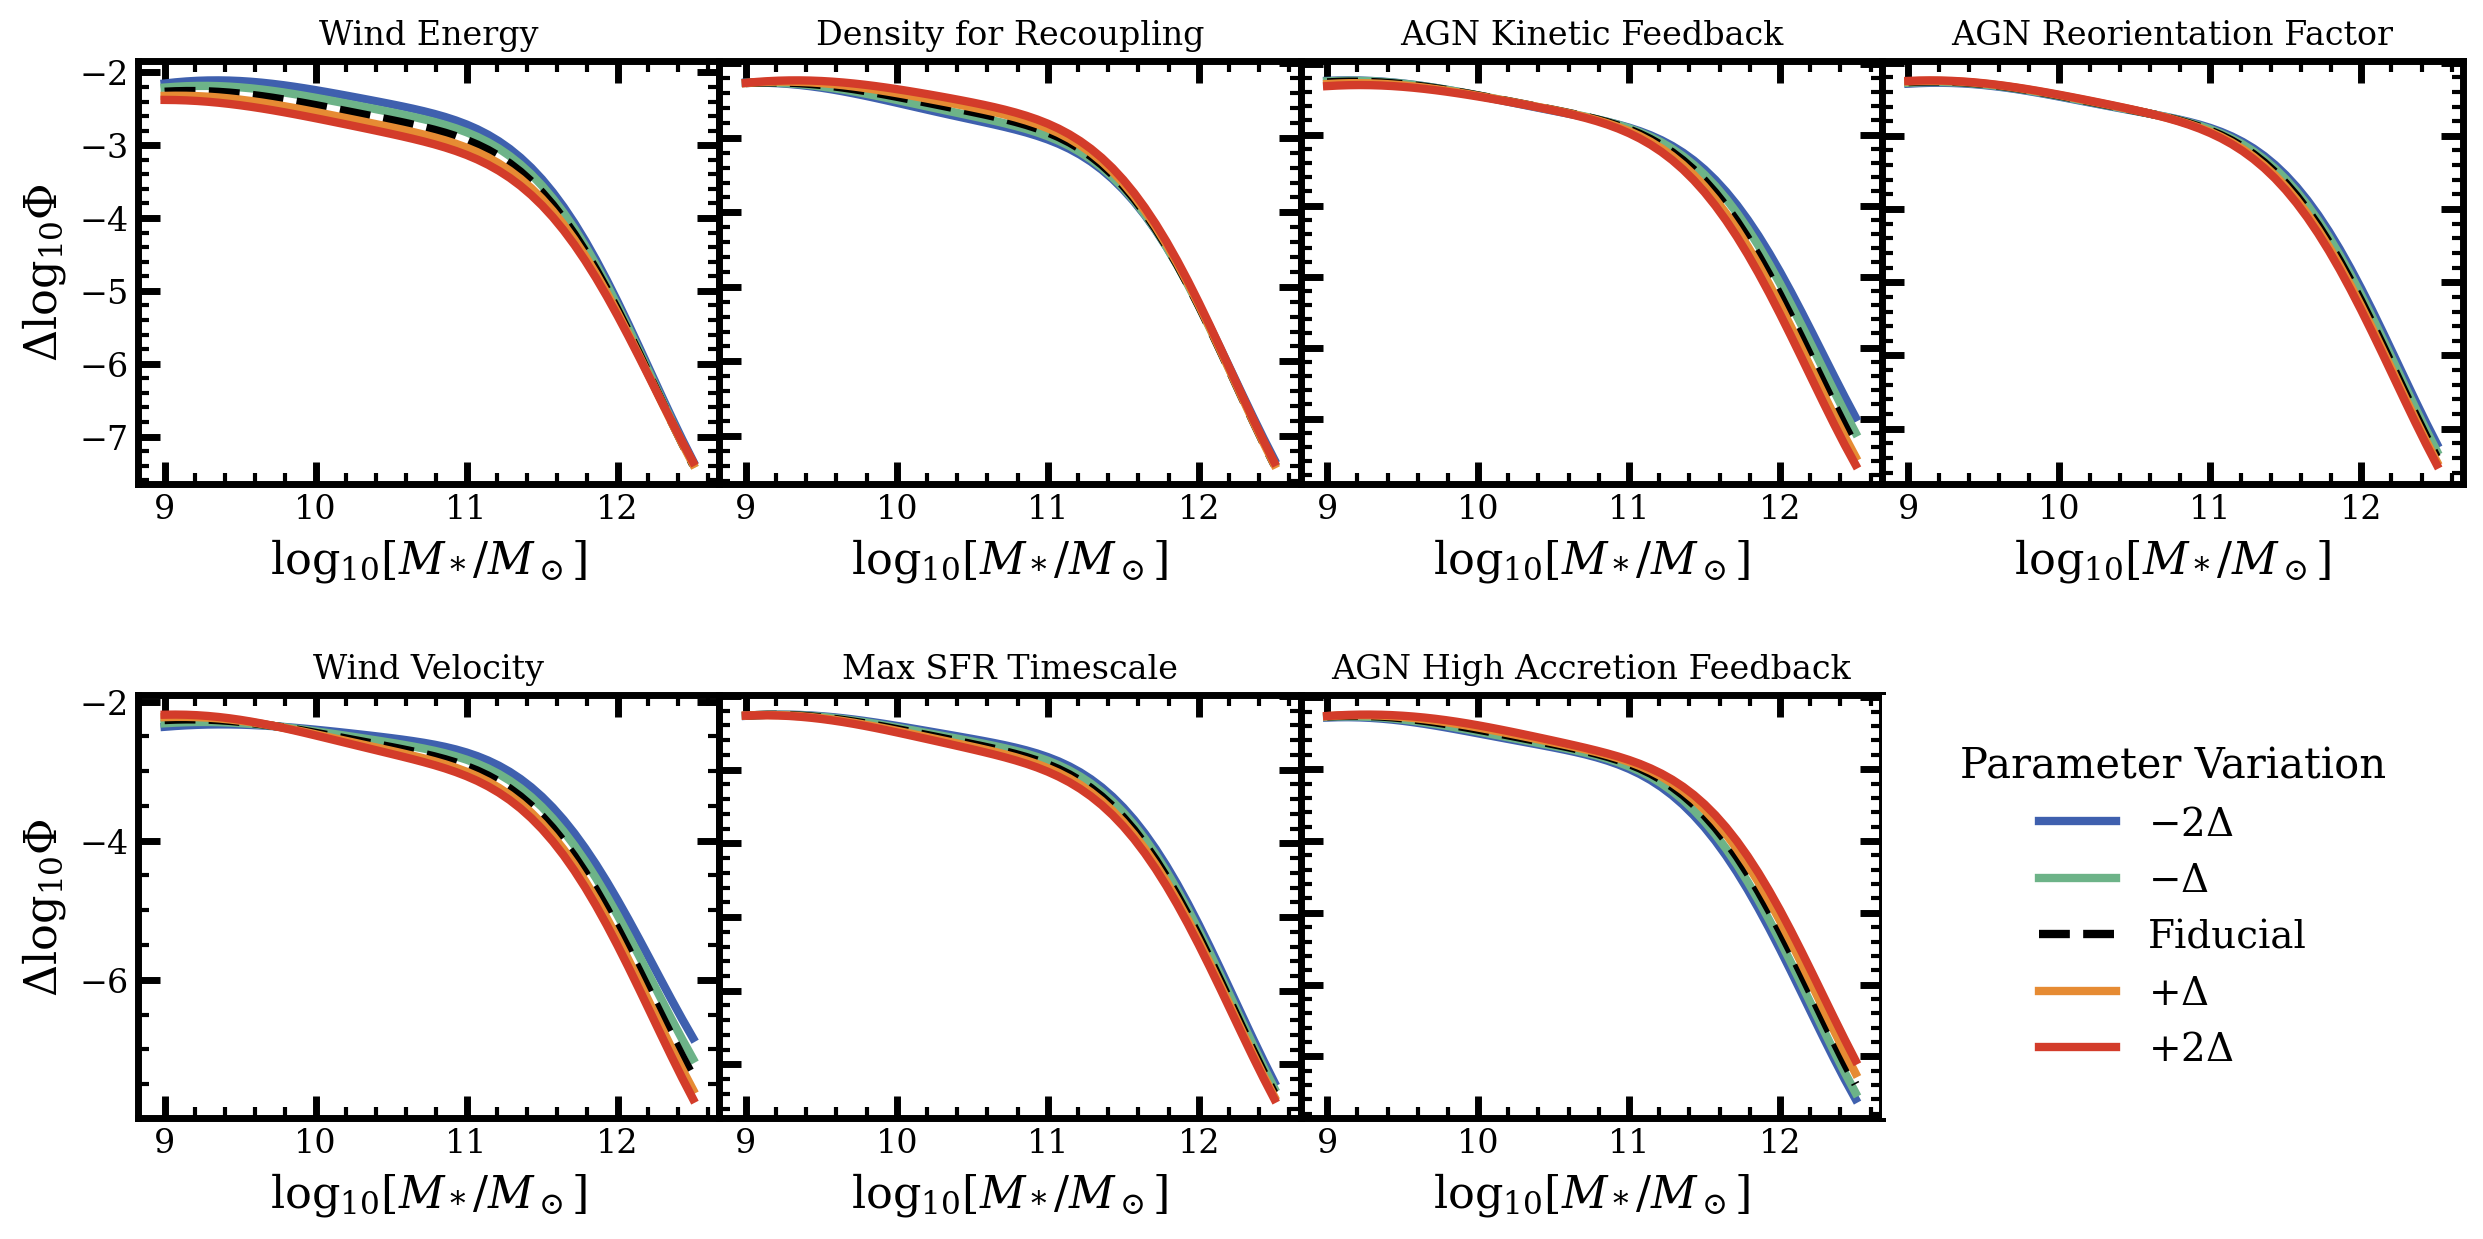

In [25]:
fig, ax = plt.subplots(2, 4, dpi=200, sharey=False, figsize=(15,7))

# Paul Tol's discrete rainbow scheme - selecting 4 well-separated colors
# for the -2Δ, -Δ, +Δ, +2Δ variations (Fiducial stays black)
tol_rainbow = ['#3F60AE', '#6DB388', '#E68B33', '#D33C2A']  # blue, green, orange, red

mstar_test = np.linspace(9,12.5,50)
names = ['Wind Energy', 'Wind Velocity', 'Density for Recoupling', 'Max SFR Timescale', 'AGN Kinetic Feedback', 'AGN High Accretion Feedback', 'AGN Reorientation Factor']

for ax_i in np.ndarray.flatten(ax):
    # ax_i.set_ylim(-0.4,0.4)
    # Thicker plot edges
    for spine in ax_i.spines.values():
        spine.set_linewidth(2.5)

    # Major and minor ticks
    ax_i.tick_params(axis='both', which='major', width=2.5, length=8, labelsize=12, direction='in', right=True, top=True)
    ax_i.tick_params(axis='both', which='minor', width=1.5, length=4, direction='in', right=True, top=True)
    ax_i.minorticks_on()

labels=['$-2\Delta$', '$-\Delta$', 'Fiducial', '$+\Delta$', '$+2\Delta$']

# Map n=0,1,3,4 to tol_rainbow indices 0,1,2,3
color_map = {0: tol_rainbow[0], 1: tol_rainbow[1], 3: tol_rainbow[2], 4: tol_rainbow[3]}

for i in range(2):
    for j in range(4):
        if 2*j+i >= 7:
            ax[i,j].set_xticks([])
            ax[i,j].set_yticks([])
            for spine in ax[i,j].spines.values():
                spine.set_visible(False)
            ax[i,j].minorticks_off()
            continue

        ax[i,j].set_title(names[2*j+i])
        ax[i,j].set_xlabel(r"$\log_{10}[M_*/M_\odot]$", fontsize=16)
        theta_vars = get_theta_1p_vars(2*j+i, mstar_test, 5)

        mu_fid, var_fid = model_smf(torch.asarray(theta_vars[2], dtype=torch.float)).mean.detach().numpy(), model_smf(torch.asarray(theta_vars[2], dtype=torch.float)).variance.detach().numpy()

        for n in range(5):
            mu_pred, var = model_smf(torch.asarray(theta_vars[n], dtype=torch.float)).mean.detach().numpy(), model_smf(torch.asarray(theta_vars[n], dtype=torch.float)).variance.detach().numpy()
            if n == 2:
                ax[i,j].plot(mstar_test, mu_pred, label="Fiducial", ls='--', color='k', lw=3)
            else:
                ax[i,j].plot(mstar_test, mu_pred, color=color_map[n], label=labels[n], lw=3)

for i in range(3):
    ax[0,i+1].set_yticklabels([])
    ax[1,i+1].set_yticklabels([])

# Y-axis labels on the leftmost column
ax[0,0].set_ylabel(r"$\Delta \log_{10}\Phi$", fontsize=16)
ax[1,0].set_ylabel(r"$\Delta \log_{10}\Phi$", fontsize=16)

# Legend in the empty panel
handles, leg_labels = ax[0,0].get_legend_handles_labels()
order = [0, 1, 2, 3, 4]
handles = [handles[k] for k in order]
leg_labels = [leg_labels[k] for k in order]

ax[1,3].legend(handles, leg_labels, loc='center', fontsize=14, frameon=False, title='Parameter Variation', title_fontsize=15)

plt.subplots_adjust(wspace=0.0, hspace=0.5)